In [18]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
#pd.set_option('display.precision', 20)

# Collisions with new mass less than min_frag_mass and collisions with the sun

In [19]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [20]:
famtree_column_names = [
    "t", "type", "new_id", "parent1_id", "parent2_id",
    "new_mass", "parent1_mass", "parent2_mass", "new_radius",
    "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
]

heartbeat_column_names = [
    "t", "walltime", "N", "total_mass", 
    "ang_mom_x", "ang_mom_y", "ang_mom_z", "energy", 
    "p3_m", "p3_r", "p3_x", "p3_y", "p3_z", "p3_vx", "p3_vy", "p3_vz",
    "p0_m", "p0_r", "p0_x", "p0_y", "p0_z", "p0_vx", "p0_vy", "p0_vz"
]

all_famtrees = []
all_heartbeats = []

# Loop through randseed 1 to 20
for randseed in range(1, 11):
    famtree_file = f"famtree_bigstep_{randseed}"
    heartbeat_file = f"heartbeat_bigstep_{randseed}"
    
    # Check if both files exist before processing
    if os.path.exists(famtree_file) and os.path.exists(heartbeat_file):
        
        # --- 1. Process Famtree ---
        df_fam = pd.read_csv(famtree_file, header=None, names=famtree_column_names)
        df_fam["randseed"] = randseed
        all_famtrees.append(df_fam)
        
        # --- 2. Process Heartbeat ---
        df_hb = pd.read_csv(heartbeat_file, header=None, names=heartbeat_column_names)
        
        # Get initial values for this specific run
        initial_mass = df_hb["total_mass"].iloc[0]
        initial_energy = df_hb["energy"].iloc[0]
        
        L_x0 = df_hb["ang_mom_x"].iloc[0]
        L_y0 = df_hb["ang_mom_y"].iloc[0]
        L_z0 = df_hb["ang_mom_z"].iloc[0]
        initial_L_mag = np.sqrt(L_x0**2 + L_y0**2 + L_z0**2)
        
        # Calculate current angular momentum
        current_L_mag = np.sqrt(
            df_hb["ang_mom_x"]**2 + 
            df_hb["ang_mom_y"]**2 + 
            df_hb["ang_mom_z"]**2
        )
        
        # Add the relative error columns
        df_hb["mass_error"] = abs((df_hb["total_mass"] - initial_mass) / initial_mass)
        df_hb["energy_error"] = abs((df_hb["energy"] - initial_energy) / initial_energy)
        df_hb["angular_momentum_error"] = abs((current_L_mag - initial_L_mag) / initial_L_mag)
        
        # Add randseed identifier
        df_hb["randseed"] = randseed
        all_heartbeats.append(df_hb)
        
    else:
        print(f"Skipping randseed {randseed}: One or both files missing.")

# Combine all the collected DataFrames into two large DataFrames
combined_famtree = pd.concat(all_famtrees, ignore_index=True)
combined_heartbeat = pd.concat(all_heartbeats, ignore_index=True)

In [21]:
famtree_less_than_min_mass = combined_famtree[combined_famtree['new_mass'] < 1.4e-8]
famtree_less_than_min_mass

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,randseed


In [22]:
famtree_with_sun = combined_famtree[(np.isclose(combined_famtree['parent1_mass'], 1)) | (np.isclose(combined_famtree['parent2_mass'], 1))]
famtree_with_sun

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,randseed
43,24276.65,3,88,0,85,1.0,1.000000e+00,4.213810e-08,0.00465,0.004650,0.000013,132.4599,0.105358,1
49,24278.96,1,96,88,94,1.0,1.000000e+00,1.632423e-08,0.00465,0.004650,0.000009,128.7768,0.984469,1
54,24296.49,1,103,96,98,1.0,1.000000e+00,1.400000e-08,0.00465,0.004650,0.000009,129.0784,1.122061,1
55,26757.07,1,105,103,99,1.0,1.000000e+00,1.721253e-08,0.00465,0.004650,0.000009,127.4460,1.569711,1
80,42704.38,3,134,130,105,1.0,3.923048e-08,1.000000e+00,0.00465,0.000012,0.004650,133.0480,0.449756,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,231184.00,1,242,234,156,1.0,1.000000e+00,1.403629e-08,0.00465,0.004650,0.000009,128.4818,1.570766,9
1548,224555.70,3,196,0,130,1.0,1.000000e+00,1.403736e-08,0.00465,0.004650,0.000009,130.4442,0.845512,10
1549,224555.70,3,198,196,129,1.0,1.000000e+00,1.510591e-08,0.00465,0.004650,0.000009,133.1911,1.048198,10
1550,224577.70,1,200,198,128,1.0,1.000000e+00,1.474867e-08,0.00465,0.004650,0.000009,129.4309,1.569848,10


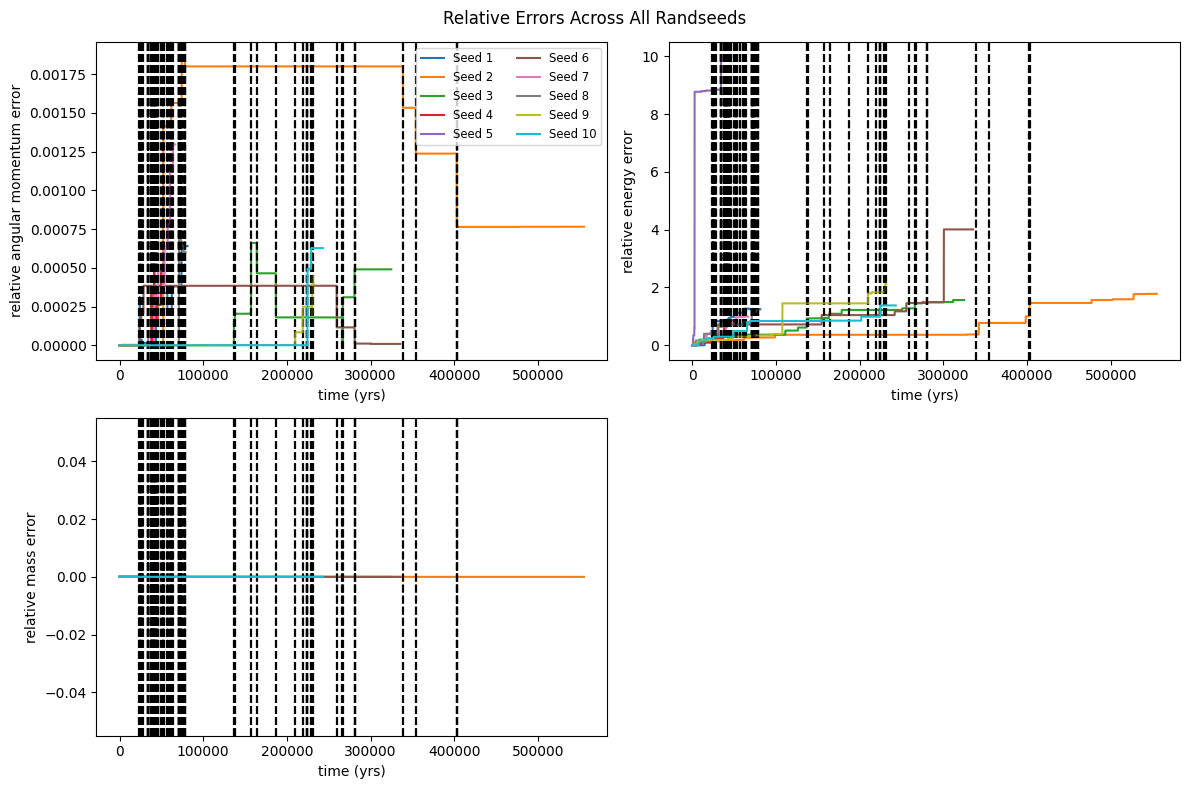

In [23]:
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 2, 3)

# Loop through each unique randseed
for seed in combined_heartbeat['randseed'].unique():
    
    # Filter the DataFrame for the current seed
    subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
    
    # Plot using lines (plt.plot) instead of scatter
    for coll_sun_t in famtree_with_sun['t']:
        ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
        ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
        ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

    ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
    ax2.plot(subset['t'], subset['energy_error'])
    ax3.plot(subset['t'], subset['mass_error'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("relative mass error")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

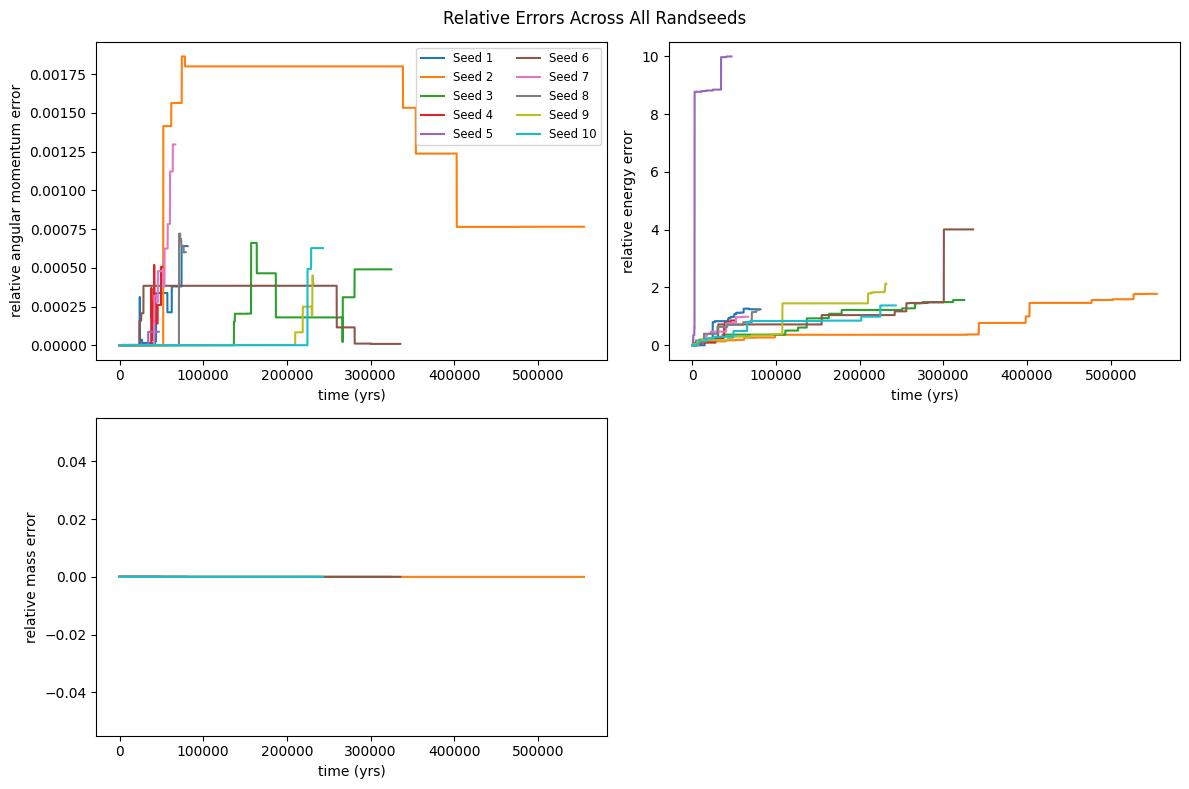

In [24]:
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 2, 3)

# Loop through each unique randseed
for seed in combined_heartbeat['randseed'].unique():
    
    # Filter the DataFrame for the current seed
    subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
    
    # Plot using lines (plt.plot) instead of scatter
    #for coll_sun_t in famtree_with_sun['t']:
        #ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
        #ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
        #ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

    ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
    ax2.plot(subset['t'], subset['energy_error'])
    ax3.plot(subset['t'], subset['mass_error'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("relative mass error")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

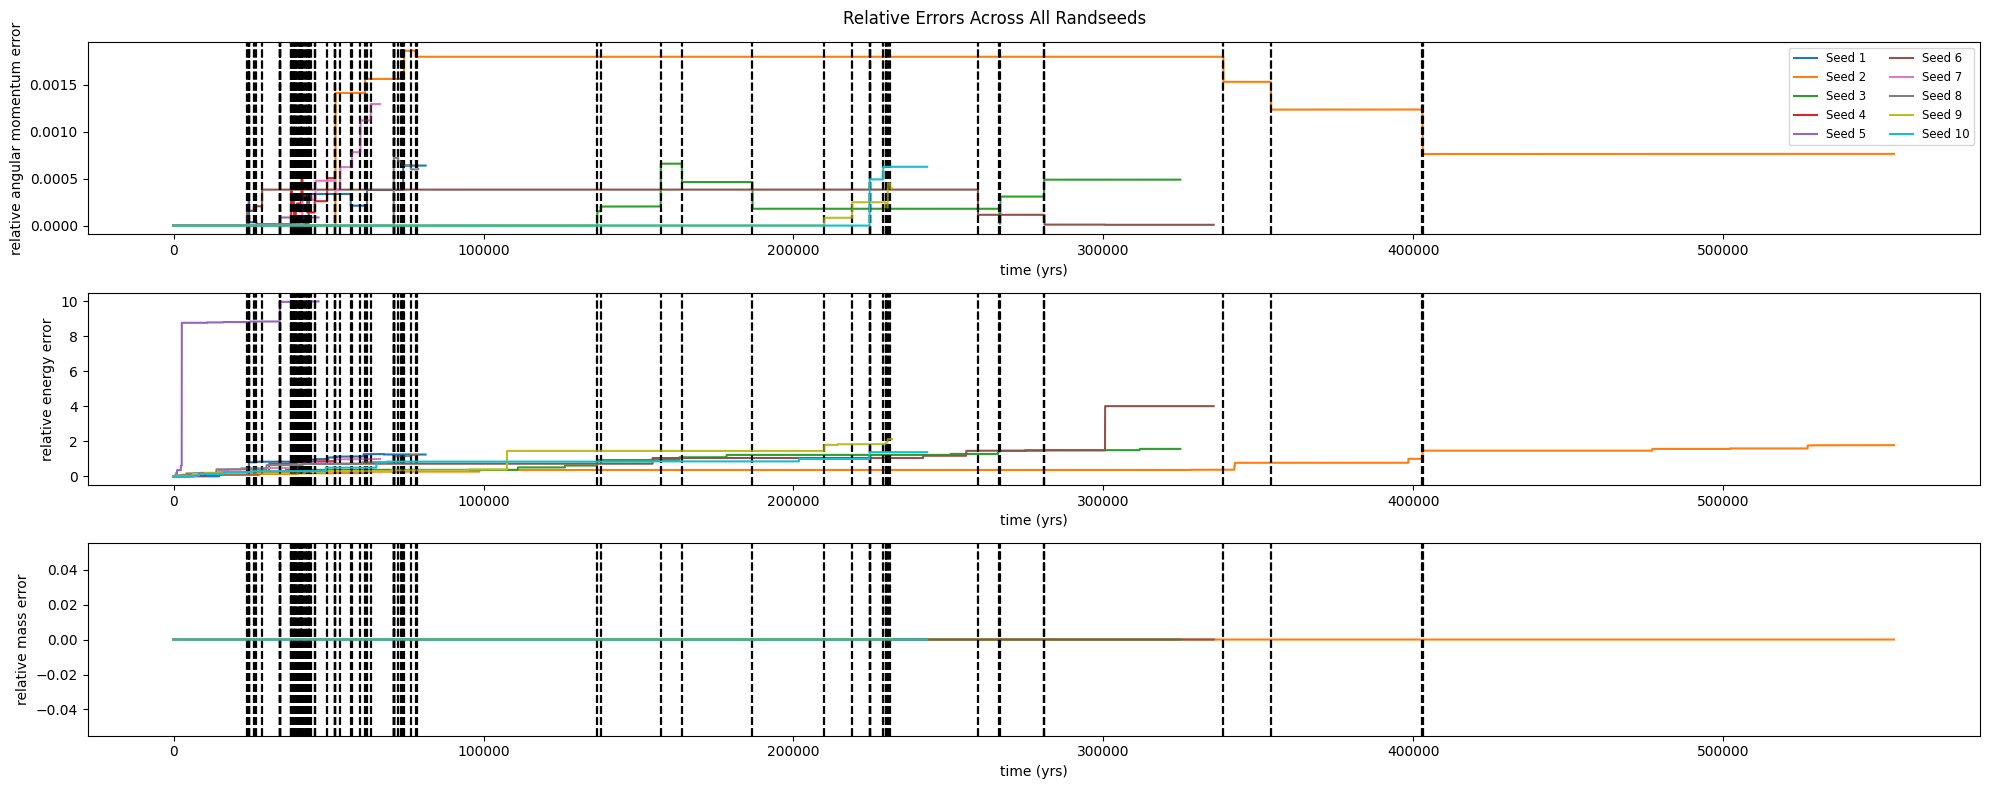

In [25]:
plt.figure(figsize=(20, 8))

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2)
ax3 = plt.subplot(3, 1, 3)

# Loop through each unique randseed
for seed in combined_heartbeat['randseed'].unique():
    
    # Filter the DataFrame for the current seed
    subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
    
    # Plot using lines (plt.plot) instead of scatter
    for coll_sun_t in famtree_with_sun['t']:
        ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
        ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
        ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

    ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
    ax2.plot(subset['t'], subset['energy_error'])
    ax3.plot(subset['t'], subset['mass_error'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("relative mass error")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

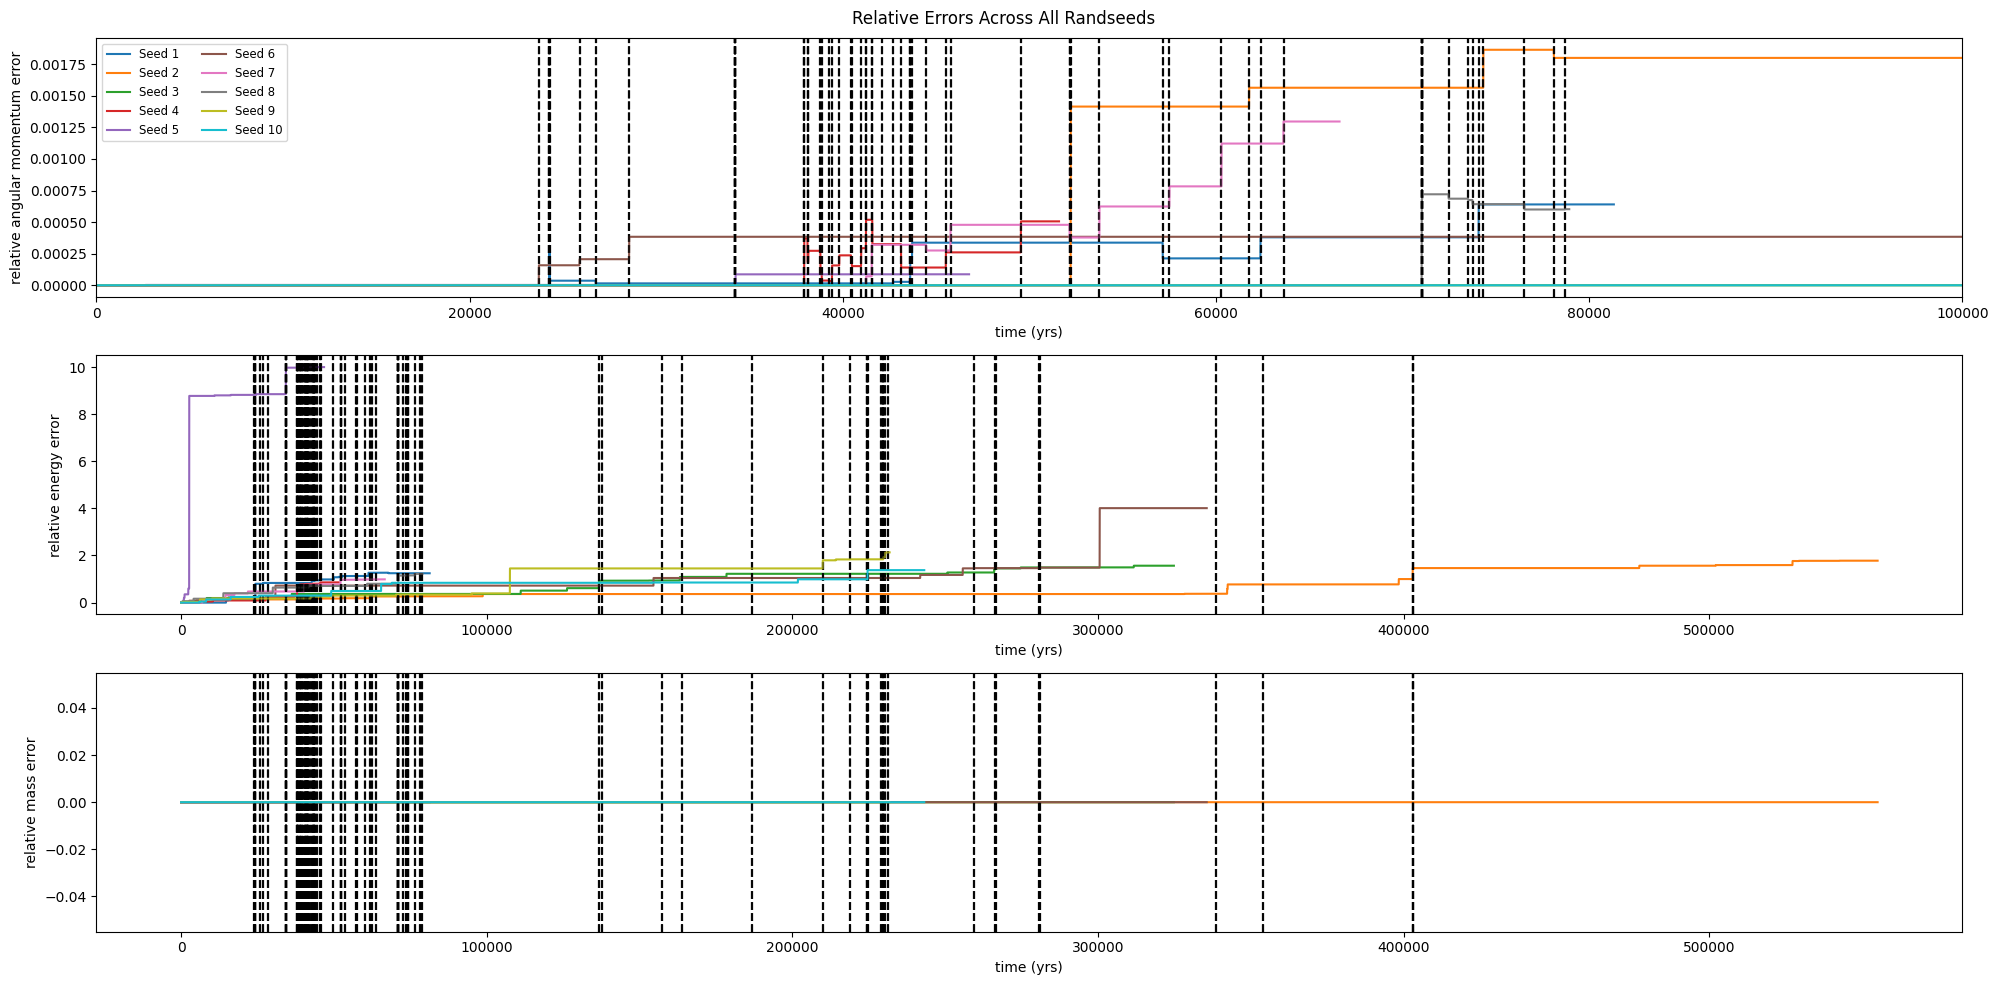

In [26]:
plt.figure(figsize=(20, 10))

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2)
ax3 = plt.subplot(3, 1, 3)

# Loop through each unique randseed
for seed in combined_heartbeat['randseed'].unique():
    
    # Filter the DataFrame for the current seed
    subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
    
    # Plot using lines (plt.plot) instead of scatter
    for coll_sun_t in famtree_with_sun['t']:
        ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
        ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
        ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

    ax1.set_xlim(0,1e5)
    ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
    ax2.plot(subset['t'], subset['energy_error'])
    ax3.plot(subset['t'], subset['mass_error'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("relative mass error")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

In [27]:
famtree_with_sun

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,randseed
43,24276.65,3,88,0,85,1.0,1.000000e+00,4.213810e-08,0.00465,0.004650,0.000013,132.4599,0.105358,1
49,24278.96,1,96,88,94,1.0,1.000000e+00,1.632423e-08,0.00465,0.004650,0.000009,128.7768,0.984469,1
54,24296.49,1,103,96,98,1.0,1.000000e+00,1.400000e-08,0.00465,0.004650,0.000009,129.0784,1.122061,1
55,26757.07,1,105,103,99,1.0,1.000000e+00,1.721253e-08,0.00465,0.004650,0.000009,127.4460,1.569711,1
80,42704.38,3,134,130,105,1.0,3.923048e-08,1.000000e+00,0.00465,0.000012,0.004650,133.0480,0.449756,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,231184.00,1,242,234,156,1.0,1.000000e+00,1.403629e-08,0.00465,0.004650,0.000009,128.4818,1.570766,9
1548,224555.70,3,196,0,130,1.0,1.000000e+00,1.403736e-08,0.00465,0.004650,0.000009,130.4442,0.845512,10
1549,224555.70,3,198,196,129,1.0,1.000000e+00,1.510591e-08,0.00465,0.004650,0.000009,133.1911,1.048198,10
1550,224577.70,1,200,198,128,1.0,1.000000e+00,1.474867e-08,0.00465,0.004650,0.000009,129.4309,1.569848,10


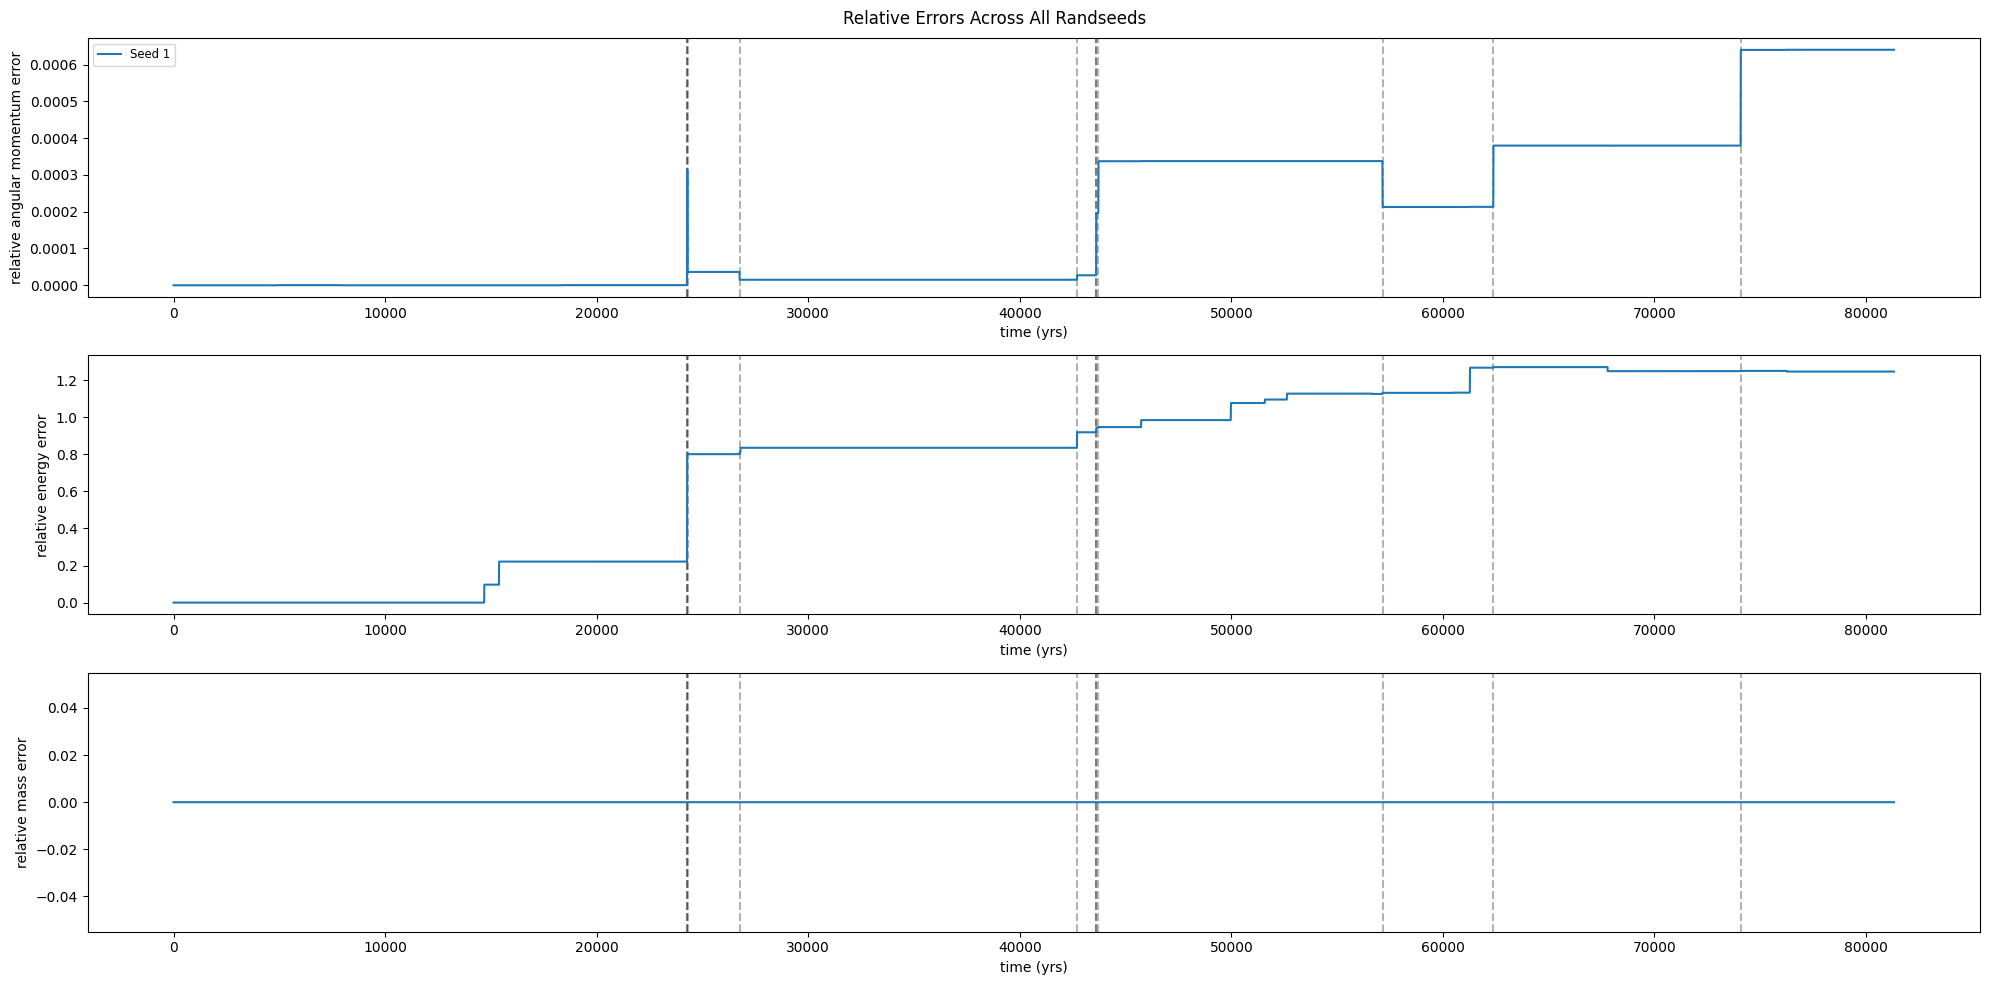

In [28]:
plt.figure(figsize=(20, 10))

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2)
ax3 = plt.subplot(3, 1, 3)

# Loop through each unique randseed
seed = 1
# Filter the DataFrame for the current seed
subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
subset_famtree_with_sun = famtree_with_sun[famtree_with_sun['randseed'] == seed]
    
# Plot using lines (plt.plot) instead of scatter
for coll_sun_t in subset_famtree_with_sun['t']:
    ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

#ax1.set_xlim(0,1e5)
ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
ax2.plot(subset['t'], subset['energy_error'])
ax3.plot(subset['t'], subset['mass_error'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("relative mass error")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

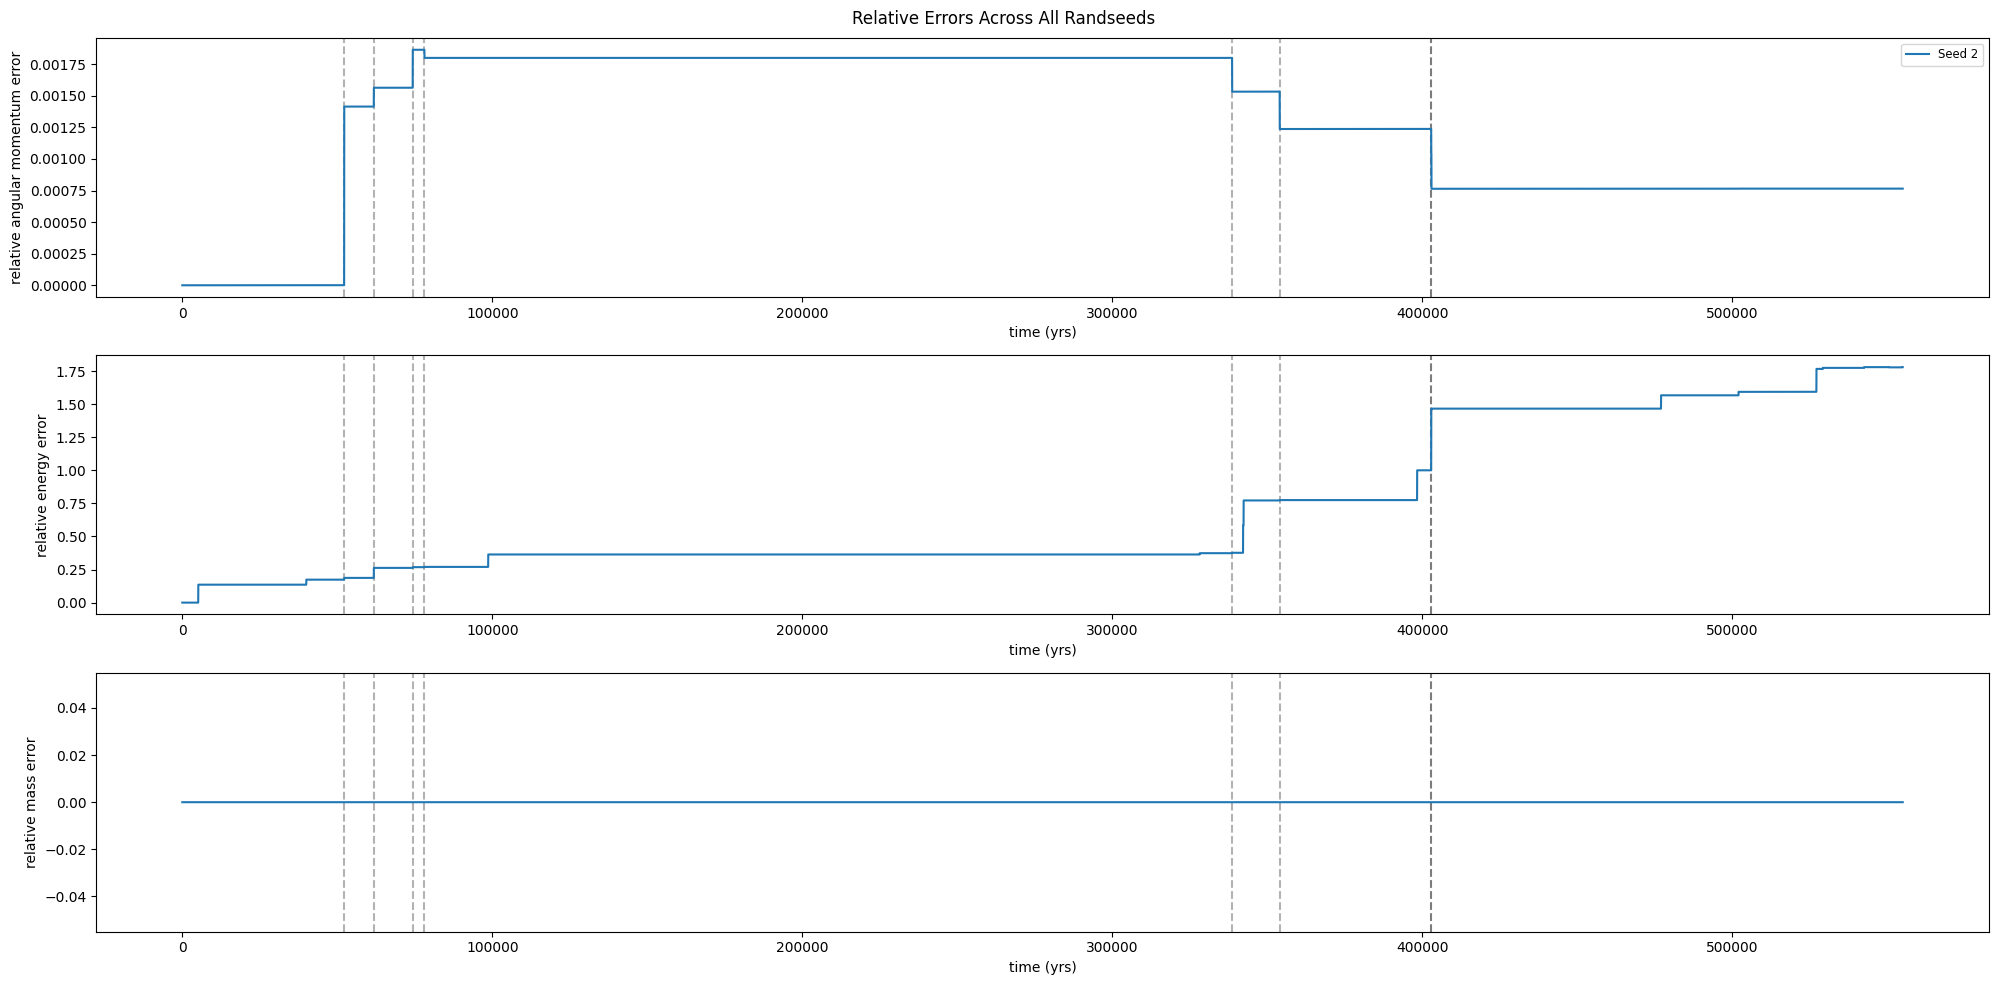

In [29]:
plt.figure(figsize=(20, 10))

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2)
ax3 = plt.subplot(3, 1, 3)

# Loop through each unique randseed
seed = 2
# Filter the DataFrame for the current seed
subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
subset_famtree_with_sun = famtree_with_sun[famtree_with_sun['randseed'] == seed]
    
# Plot using lines (plt.plot) instead of scatter
for coll_sun_t in subset_famtree_with_sun['t']:
    ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

#ax1.set_xlim(0,1e5)
ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
ax2.plot(subset['t'], subset['energy_error'])
ax3.plot(subset['t'], subset['mass_error'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("relative mass error")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

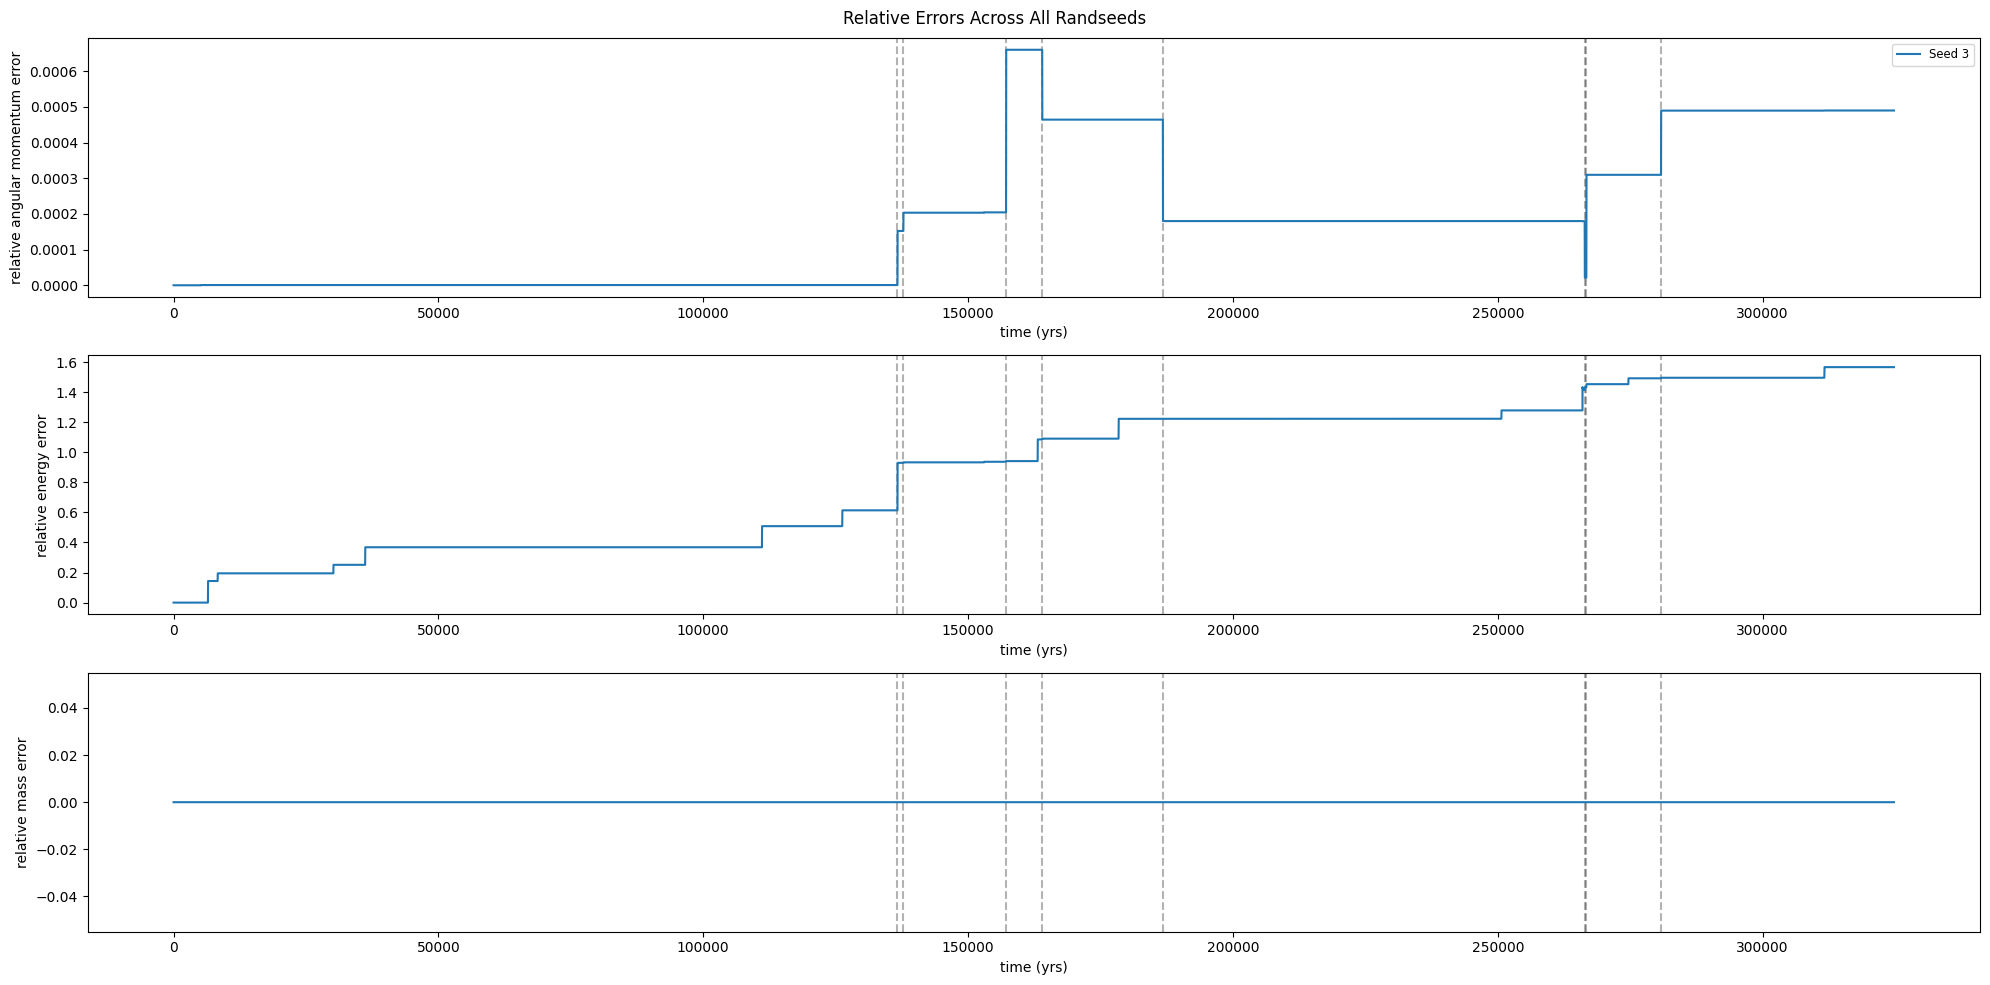

In [30]:
plt.figure(figsize=(20, 10))

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2)
ax3 = plt.subplot(3, 1, 3)

# Loop through each unique randseed
seed = 3
# Filter the DataFrame for the current seed
subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
subset_famtree_with_sun = famtree_with_sun[famtree_with_sun['randseed'] == seed]
    
# Plot using lines (plt.plot) instead of scatter
for coll_sun_t in subset_famtree_with_sun['t']:
    ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

#ax1.set_xlim(0,1e5)
ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
ax2.plot(subset['t'], subset['energy_error'])
ax3.plot(subset['t'], subset['mass_error'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("relative mass error")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

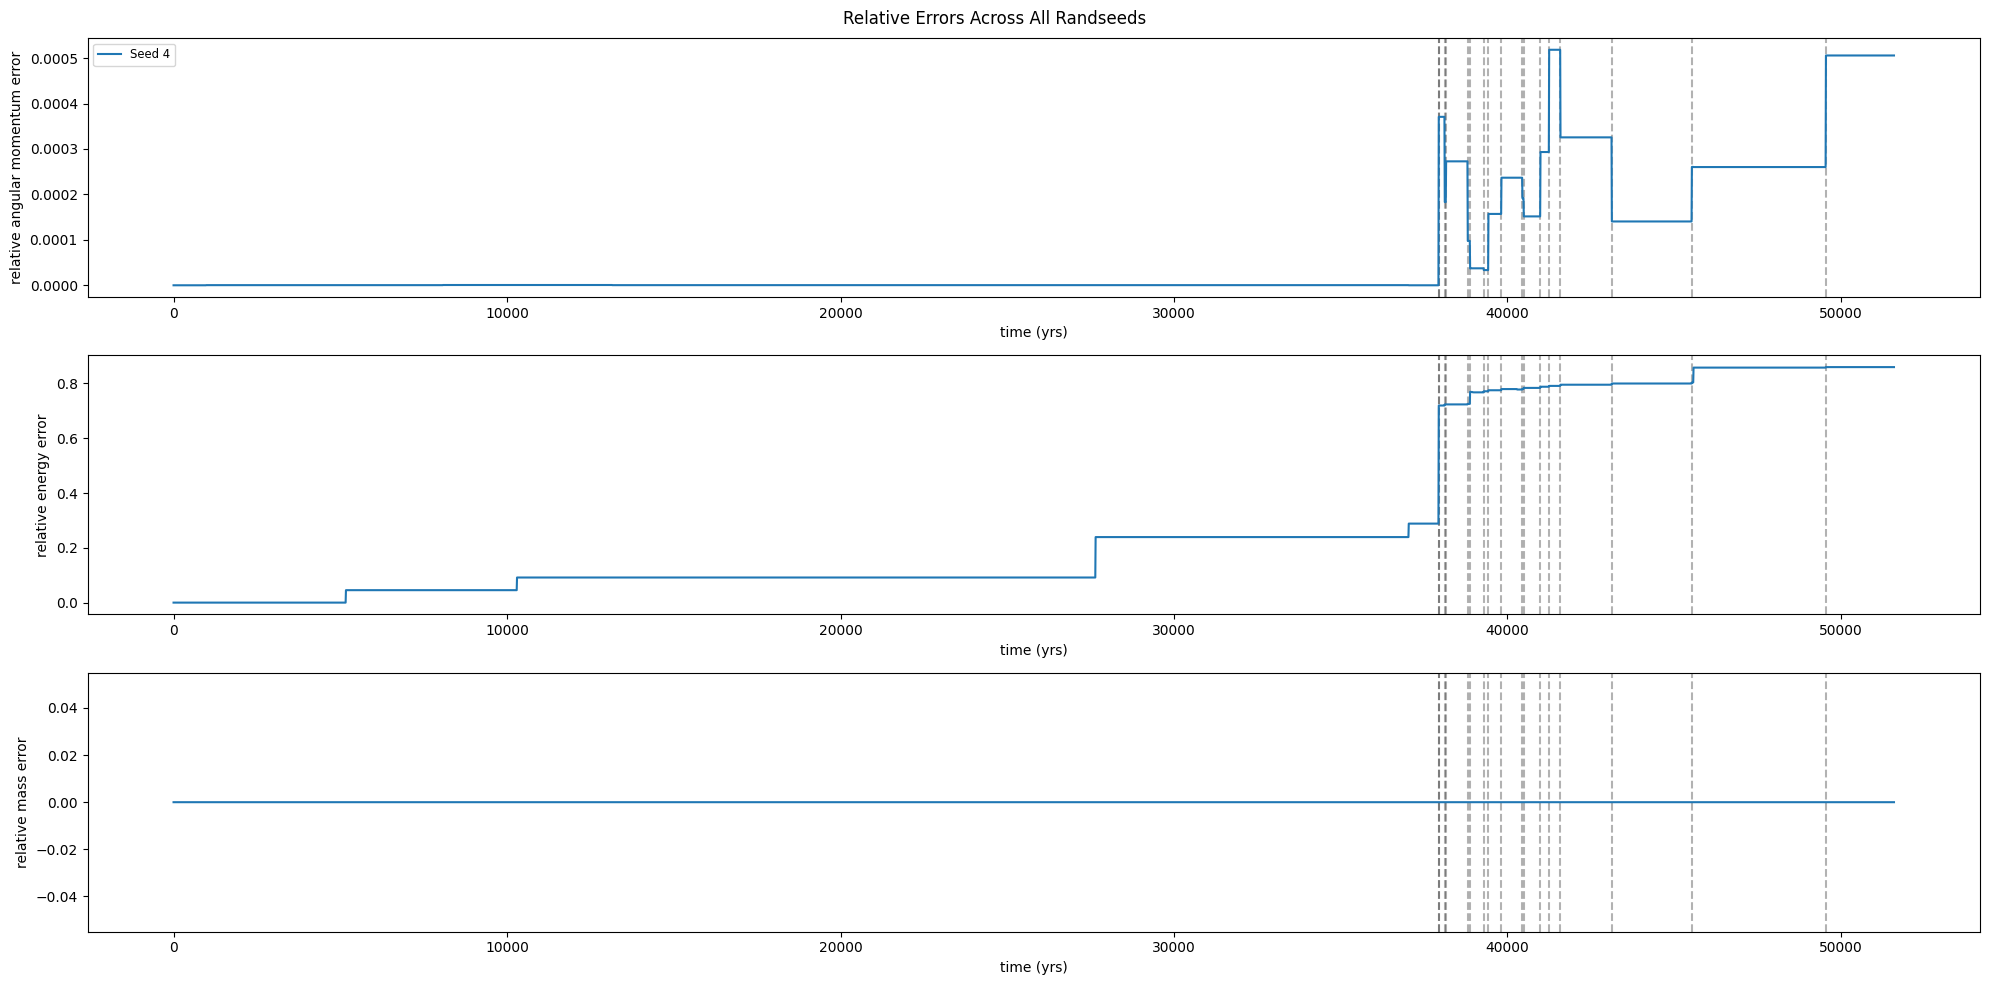

In [31]:
plt.figure(figsize=(20, 10))

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2)
ax3 = plt.subplot(3, 1, 3)

# Loop through each unique randseed
seed = 4
# Filter the DataFrame for the current seed
subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
subset_famtree_with_sun = famtree_with_sun[famtree_with_sun['randseed'] == seed]
    
# Plot using lines (plt.plot) instead of scatter
for coll_sun_t in subset_famtree_with_sun['t']:
    ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

#ax1.set_xlim(0,1e5)
ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
ax2.plot(subset['t'], subset['energy_error'])
ax3.plot(subset['t'], subset['mass_error'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("relative mass error")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

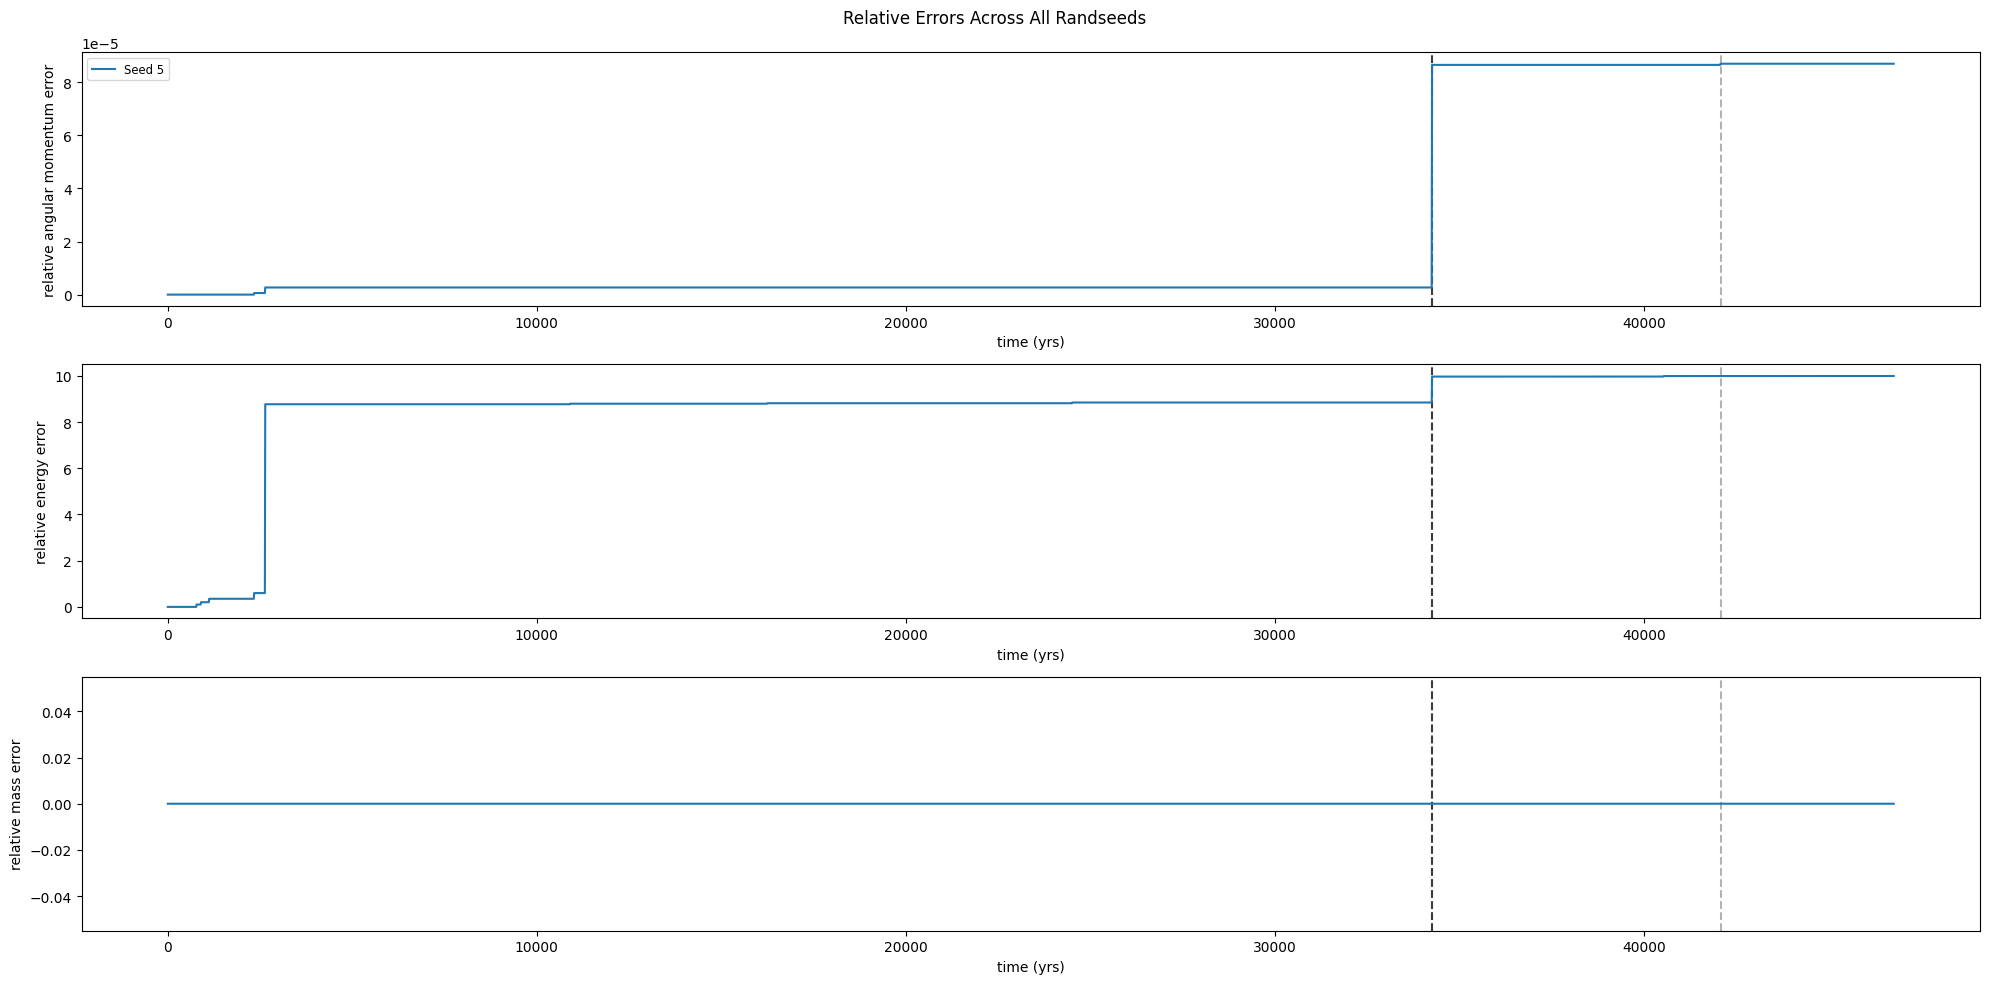

In [32]:
plt.figure(figsize=(20, 10))

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2)
ax3 = plt.subplot(3, 1, 3)

# Loop through each unique randseed
seed = 5
# Filter the DataFrame for the current seed
subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
subset_famtree_with_sun = famtree_with_sun[famtree_with_sun['randseed'] == seed]
    
# Plot using lines (plt.plot) instead of scatter
for coll_sun_t in subset_famtree_with_sun['t']:
    ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

#ax1.set_xlim(0,1e5)
ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
ax2.plot(subset['t'], subset['energy_error'])
ax3.plot(subset['t'], subset['mass_error'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("relative mass error")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

In [40]:
combined_heartbeat['abs_ang_mom'] = get_abs(combined_heartbeat['ang_mom_x'], combined_heartbeat['ang_mom_y'], combined_heartbeat['ang_mom_z'])

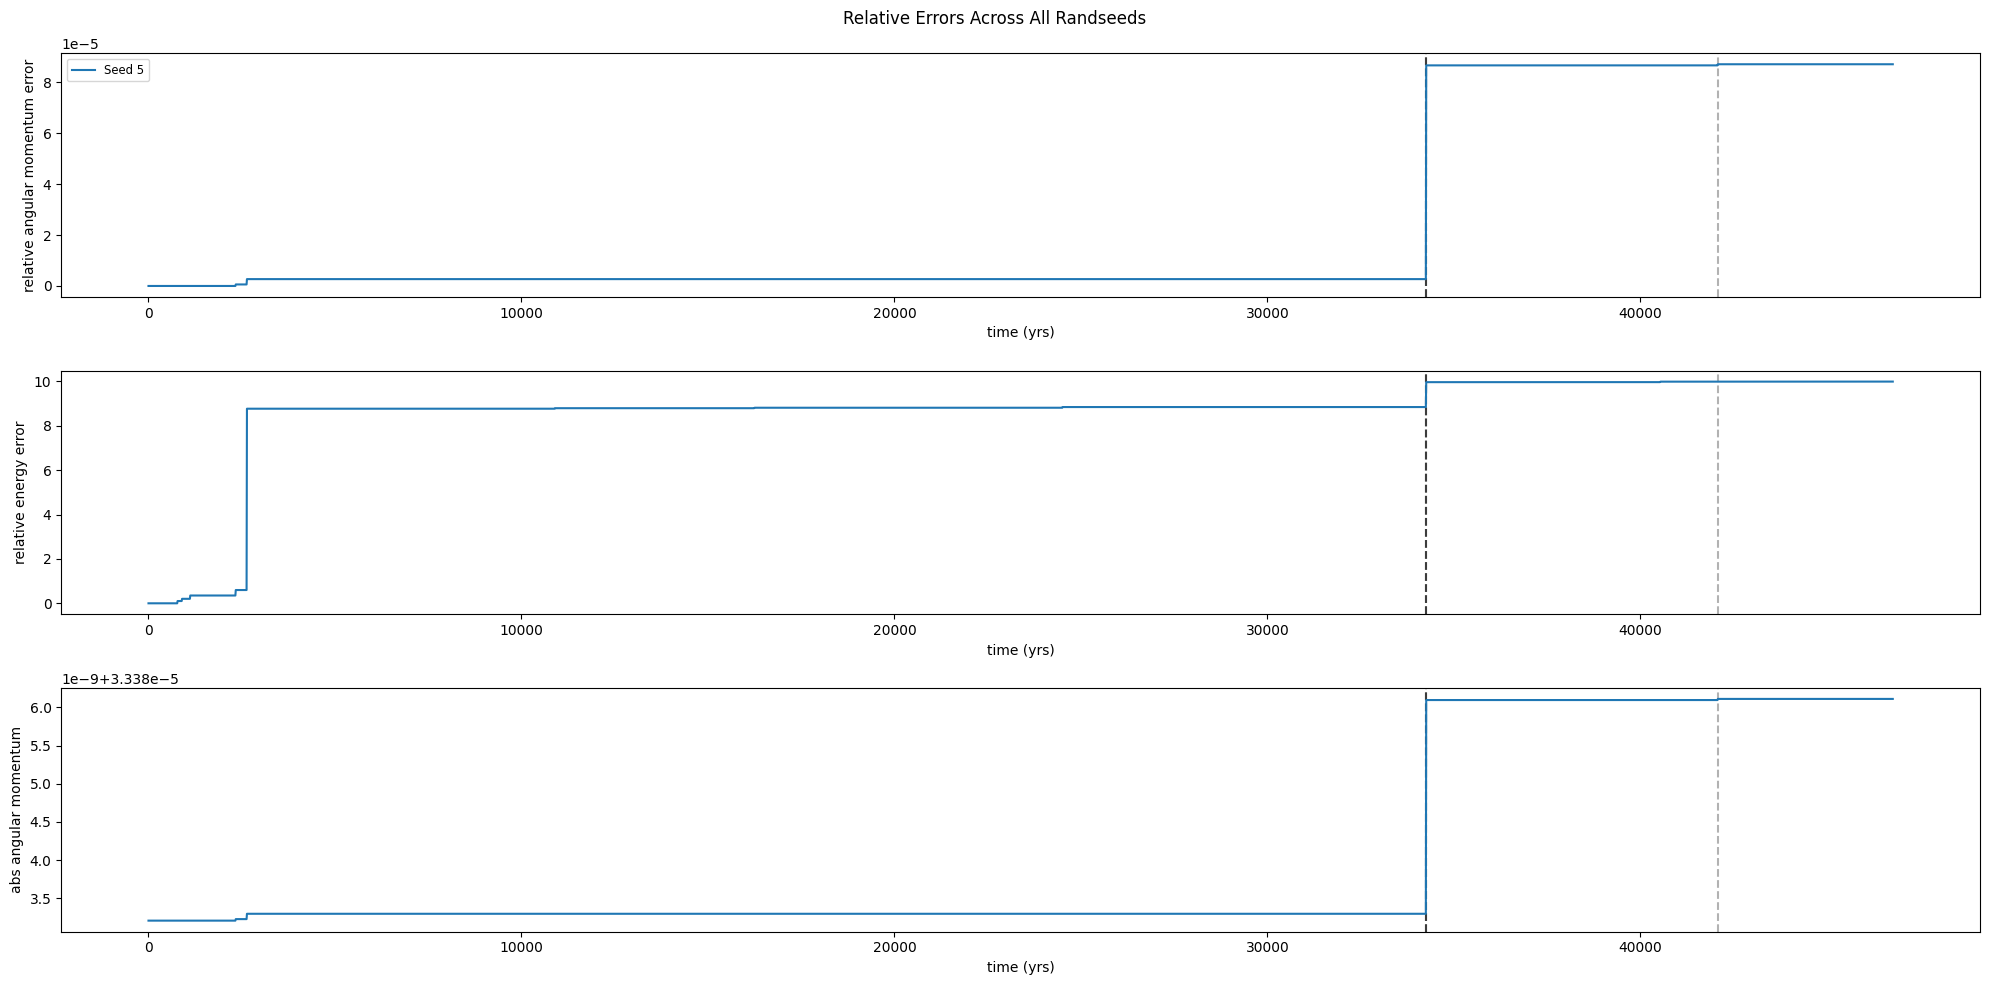

In [42]:
plt.figure(figsize=(20, 10))

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2)
ax3 = plt.subplot(3, 1, 3)

# Loop through each unique randseed
seed = 5
# Filter the DataFrame for the current seed
subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
subset_famtree_with_sun = famtree_with_sun[famtree_with_sun['randseed'] == seed]
    
# Plot using lines (plt.plot) instead of scatter
for coll_sun_t in subset_famtree_with_sun['t']:
    ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)

#ax1.set_xlim(0,1e5)
ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
ax2.plot(subset['t'], subset['energy_error'])
ax3.plot(subset['t'], subset['abs_ang_mom'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("abs angular momentum")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

34252.35
34252.35
34252.35
34252.35
42076.98


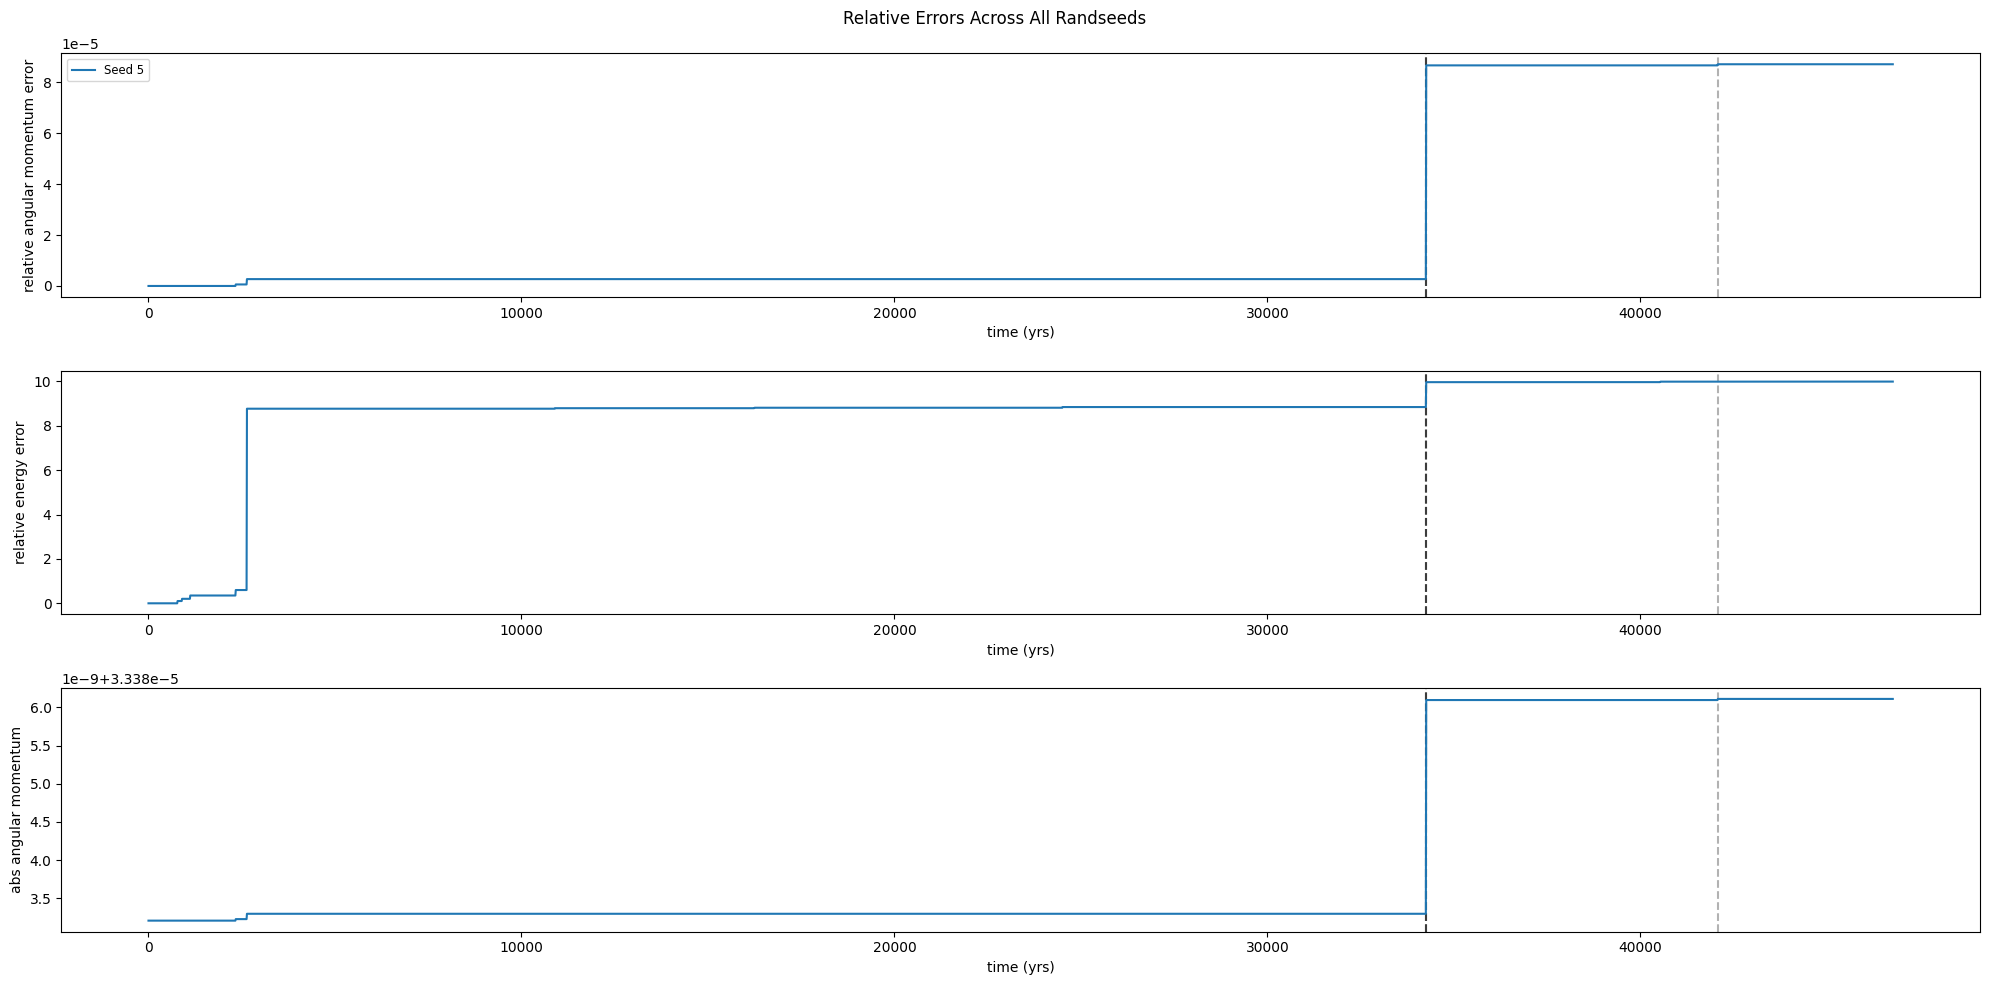

In [50]:
plt.figure(figsize=(20, 10))

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2)
ax3 = plt.subplot(3, 1, 3)

# Loop through each unique randseed
seed = 5
# Filter the DataFrame for the current seed
subset = combined_heartbeat[combined_heartbeat['randseed'] == seed]
subset_famtree_with_sun = famtree_with_sun[famtree_with_sun['randseed'] == seed]
    
# Plot using lines (plt.plot) instead of scatter
for coll_sun_t in subset_famtree_with_sun['t']:
    ax1.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax2.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    ax3.axvline(coll_sun_t, linestyle='--', color = 'black', alpha = 0.3)
    print(coll_sun_t)

#ax1.set_xlim(0,1e5)
ax1.plot(subset['t'], subset['angular_momentum_error'], label=f"Seed {seed}")
ax2.plot(subset['t'], subset['energy_error'])
ax3.plot(subset['t'], subset['abs_ang_mom'])

# Format Subplot 1
ax1.set_xlabel("time (yrs)")
ax1.set_ylabel("relative angular momentum error")
ax1.legend(fontsize='small', ncol=2)
# ax1.set_xlim() 

# Format Subplot 2
ax2.set_xlabel("time (yrs)")
ax2.set_ylabel("relative energy error")

# Format Subplot 3
ax3.set_xlabel("time (yrs)")
ax3.set_ylabel("abs angular momentum")

plt.suptitle("Relative Errors Across All Randseeds")
plt.tight_layout()
plt.show()

In [53]:
loss_summary = {}

for randseed in combined_famtree["randseed"].unique():
    # Filter datasets for this specific run and ensure time ordering
    df_fam_seed = combined_famtree[combined_famtree["randseed"] == randseed]
    df_hb_seed = combined_heartbeat[combined_heartbeat["randseed"] == randseed].sort_values("t")
    
    # Pre-filter all collision timestamps involving the Sun for this seed
    sun_collision_times = []
    for idx, row in df_fam_seed.iterrows():
        is_parent1_sun = np.isclose(row["parent1_mass"], 1.0)
        is_parent2_sun = np.isclose(row["parent2_mass"], 1.0)
        
        if is_parent1_sun or is_parent2_sun:
            sun_collision_times.append(row["t"])
            
    # Calculate magnitude of angular momentum for all heartbeat snapshots
    hb_times = df_hb_seed["t"].values
    hb_L_mag = np.sqrt(
        df_hb_seed["ang_mom_x"]**2 + 
        df_hb_seed["ang_mom_y"]**2 + 
        df_hb_seed["ang_mom_z"]**2
    ).values
    
    total_abs_L_change = 0.0
    sun_abs_L_change = 0.0
    
    # Loop through each heartbeat interval
    for i in range(1, len(hb_L_mag)):
        t_start = hb_times[i - 1]
        t_end = hb_times[i]
        
        step_diff = abs(hb_L_mag[i] - hb_L_mag[i - 1])
        total_abs_L_change = total_abs_L_change + step_diff
        
        # Check if at least one Sun collision occurred in this interval
        has_sun_collision = False
        for t_col in sun_collision_times:
            if t_start < t_col <= t_end:
                has_sun_collision = True
                break  # Found one; no need to check further collisions for this step
                
        if has_sun_collision:
            sun_abs_L_change = sun_abs_L_change + step_diff
            
    # Compute Fraction / Percentage
    if total_abs_L_change > 0:
        sun_fraction = (sun_abs_L_change / total_abs_L_change) * 100.0
    else:
        sun_fraction = 0.0
        
    loss_summary[randseed] = {
        "total_abs_change": total_abs_L_change,
        "sun_abs_change": sun_abs_L_change,
        "sun_percentage": sun_fraction
    }

# Print comparison
print(f"{'Randseed':<10} | {'Total |ΔL|':<16} | {'Sun |ΔL|':<20} | {'% Due to Sun'}")
print("-" * 65)
for seed, data in loss_summary.items():
    print(f"{seed:<10} | {data['total_abs_change']:<16.6e} | {data['sun_abs_change']:<20.6e} | {data['sun_percentage']:.2f}%")

Randseed   | Total |ΔL|       | Sun |ΔL|             | % Due to Sun
-----------------------------------------------------------------
1          | 4.103883e-08     | 4.093881e-08         | 99.76%
2          | 7.850152e-08     | 7.836138e-08         | 99.82%
3          | 6.567805e-08     | 6.560798e-08         | 99.89%
4          | 8.501236e-08     | 8.495236e-08         | 99.93%
5          | 2.905201e-09     | 2.815280e-09         | 96.90%
6          | 3.393585e-08     | 3.379561e-08         | 99.59%
7          | 5.589726e-08     | 5.582727e-08         | 99.87%
8          | 2.496624e-08     | 2.490619e-08         | 99.76%
9          | 1.959682e-08     | 1.952671e-08         | 99.64%
10         | 2.214853e-08     | 2.206862e-08         | 99.64%
